In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_EnergyCal.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_EnergyCal.ipynb started: Thu, 09 Apr 2026 11:58:12
INFO: SETUP COMPLETE (1078.12 ms)
---------------------------------------


In [2]:
def read_json_formatted_file(filepath, encoding="utf-8"):
    """
    Reads a file whose contents are JSON-formatted, regardless of file extension.

    Parameters:
        filepath (str): Path to the file
        encoding (str): File encoding (default: utf-8)

    Returns:
        dict or list: Parsed JSON content

    Raises:
        ValueError: If the file content is not valid JSON
        OSError: If the file cannot be read
    """
    with open(filepath, "r", encoding=encoding) as f:
        content = f.read()

    try:
        return json.loads(content)
    except json.JSONDecodeError as e:
        raise ValueError(f"File content is not valid JSON: {e}") from e
    
def file_collector(measurement:str):
    file_collection = []
    top_level_path = f'.//{measurement}'
    for file in os.listdir(top_level_path):
        if (file[-5:] == '.vspc'):
            full_path = top_level_path + '//' + file
            file_collection.append(full_path)
    return file_collection

def pixe_single_spectrum_plot(filename:str):
    '''
    This function will produce a simple labeled plot of uncalibrated raw-data.
    '''
    DPI = 250
    data = read_json_formatted_file(filename)
    meas_name = filename.split('//')[2].split('.')[0]
    meas_folder = filename.split('//')[1]
    
    energyPerBin = data['Calibration']['BinSize_keV/Bin'] # keV/bin
    bin_data = data['RawData'][:-1] #remove that overflow bin at position 8191
    total_counts = np.sum(bin_data)
    total_counts_incl = np.sum(data['RawData'])
    # print(bin_data)
    
    bins = np.arange(0,len(bin_data),1)
    
    scatter_color = color_schemes['c_dark']
    
    fig, ax = plt.subplots(figsize=(6,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # ax.plot(bins, bin_data, lw=0.75, color=scatter_color[0], zorder=2)
    ax.step(bins, bin_data, lw=0.75, color=scatter_color[3], zorder=2)
    
    if (len(bin_data) == 8191):
        ax.set_xlim(0,8193)
        ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    elif (len(bin_data) == 4095):
        ax.set_xlim(0,4095)
        ax.set_xticks(np.arange(0,4097,512),np.arange(0,4097,512))
    elif (len(bin_data) == 2047):
        ax.set_xlim(0,2047)
        ax.set_xticks(np.arange(0,2049,512),np.arange(0,2049,512))
        
        
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    plt.grid(which="both")
    plt.tight_layout()

    #----------------- Information Box -----------------#
    #det_pic_file = detector_pic(measurement['det_id'])
    # img = plt.imread(det_pic_file)
    annotation = TextArea(f"X-ray measurement \n {meas_name} \n RAW DATA \n Total Counts: {total_counts}", textprops=dict(color="black", fontsize=5, multialignment='center'))
    # imagebox = OffsetImage(img, zoom=0.05)
    stacked = VPacker(children=[annotation],
                 align="center",
                 pad=0,
                 sep=5)
    
    ab = AnnotationBbox(offsetbox=stacked, xy=(0.9,0.85), xycoords='axes fraction', frameon=True)

    ax.add_artist(ab)
    #----------------- Information Box -----------------#

    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}.pdf', dpi=DPI)
    
    plt.show()

def all_files_from_measSet(m_name:str):
    f_c = file_collector(m_name)
    for file in f_c:
        pixe_single_spectrum_plot(file)
    return 4

In [3]:
# pixe_single_spectrum_plot('.//2026_02_26//20260226-155629.vspc')

In [4]:
# f_n = all_files_from_measSet('2026_02_27')
# print(f_n)


In [3]:
def all_peaks_one_measurement(file:str, peaks:list, xlim:list, info:list, col_flag:bool, identifier:str):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,2,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = file.split('//')[2].split('.')[0]
    meas_folder = file.split('//')[1]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.set_facecolor(color_schemes['c_back'])
    plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
        beta= peak_fitter(file=file, init_values=peaks[p])
        beta_export = [beta['param'],beta['errors']]
        
        gauss_left = int(beta['param'][1]*0.95)
        gauss_right = int(beta['param'][1]*1.05)
        plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=0.65, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        
        csv_file_name = f'.//peak_idents{file[1:-5]}_peaks_{identifier}.csv'
        
        with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
            writer = csv.writer(csv_file)
            writer.writerows(beta_export)
        
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

In [4]:
def peak_fitter(lines:list, peaks:list, peaks_err:list, init_values:list):
    
    lines_err = np.array([1]*len(lines))
    
    beta = evaluator_scipy(func=energy_func, beta0_list=init_values,
                           x=peaks, y=lines, xerr=peaks_err, yerr=lines_err)
    
    return beta

In [5]:
def lowerLim(beta, x):
    param = beta[0]
    errors = beta[1]
    return (param[0]-errors[0]) + (param[1]-errors[1])*x + (param[2]-errors[2])*x**2

def upperLim(beta, x):
    param = beta[0]
    errors = beta[1]
    return (param[0]+errors[0]) + (param[1]+errors[1])*x + (param[2]+errors[2])*x**2

### To-Do
- Annotate specific lines
- Flags like Results

# Set A & B

## Energy Calibrations


### MCA = 8192 | Energy Gain = 4096 | 5cm

In [9]:
def EnergyCal_1(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
    # Tb_file = './/2026_02_27//20260227-153740.vspc'
    # Ba_file = './/2026_02_27//20260227-152912.vspc'
    # Ag_file = './/2026_02_27//20260227-152010.vspc'
    
    # Tb_data = read_json_formatted_file(file)
    # Ba_data = read_json_formatted_file(file)
    # Ag_data = read_json_formatted_file(file)
    
        
    Tb_lines = [43744.1, 44481.6, 50382, 6272.8, 6978]
    Ba_lines = [36378.2]
    Ag_lines = [22162.92, 24942.4]
    
    Tb_peaks_err = [1.640, 1.244, 4.074, 1.404, 1.441]
    Ba_peaks_err = [3.295]
    Ag_peaks_err = [0.448, 1.638]
    
    Tb_peaks = [6921.738, 7035.801, 7961.722, 994.595, 1108.723] # KL3, KL2, KM3, LAlpha, LBeta
    Ba_peaks = [5752.680] #KM3
    Ag_peaks = [3497.814, 3945.768] #KL3, KM3
    
    lines,peaks,peaks_err = [],[],[]
    for e in [Tb_lines, Ba_lines, Ag_lines]:
        for i in e:
            lines.append(i)
    for e in [Tb_peaks_err, Ba_peaks_err, Ag_peaks_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Tb_peaks, Ba_peaks, Ag_peaks]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Tb_peaks, Tb_lines, s=10, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Terbium')# / 20260227-153740')
    ax.scatter(Ba_peaks, Ba_lines, s=10, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Barium')# / 20260227-152912')
    ax.scatter(Ag_peaks, Ag_lines, s=10, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Silver')# / 20260227-152010')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,60000)
    ax.set_yticks([0,10000,20000,30000,40000,50000,60000],[0,10,20,30,40,50,60])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return 7


[43744.1, 44481.6, 50382, 6272.8, 6978, 36378.2, 22162.92, 24942.4]
PARAMS: [-6.88746563e+01  6.37653023e+00 -6.36631343e-06]
UNCERT: [3.32604745e+01 1.63410621e-02 1.84015727e-06]
{'param': array([-6.88746563e+01,  6.37653023e+00, -6.36631343e-06]), 'errors': array([3.32604745e+01, 1.63410621e-02, 1.84015727e-06])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


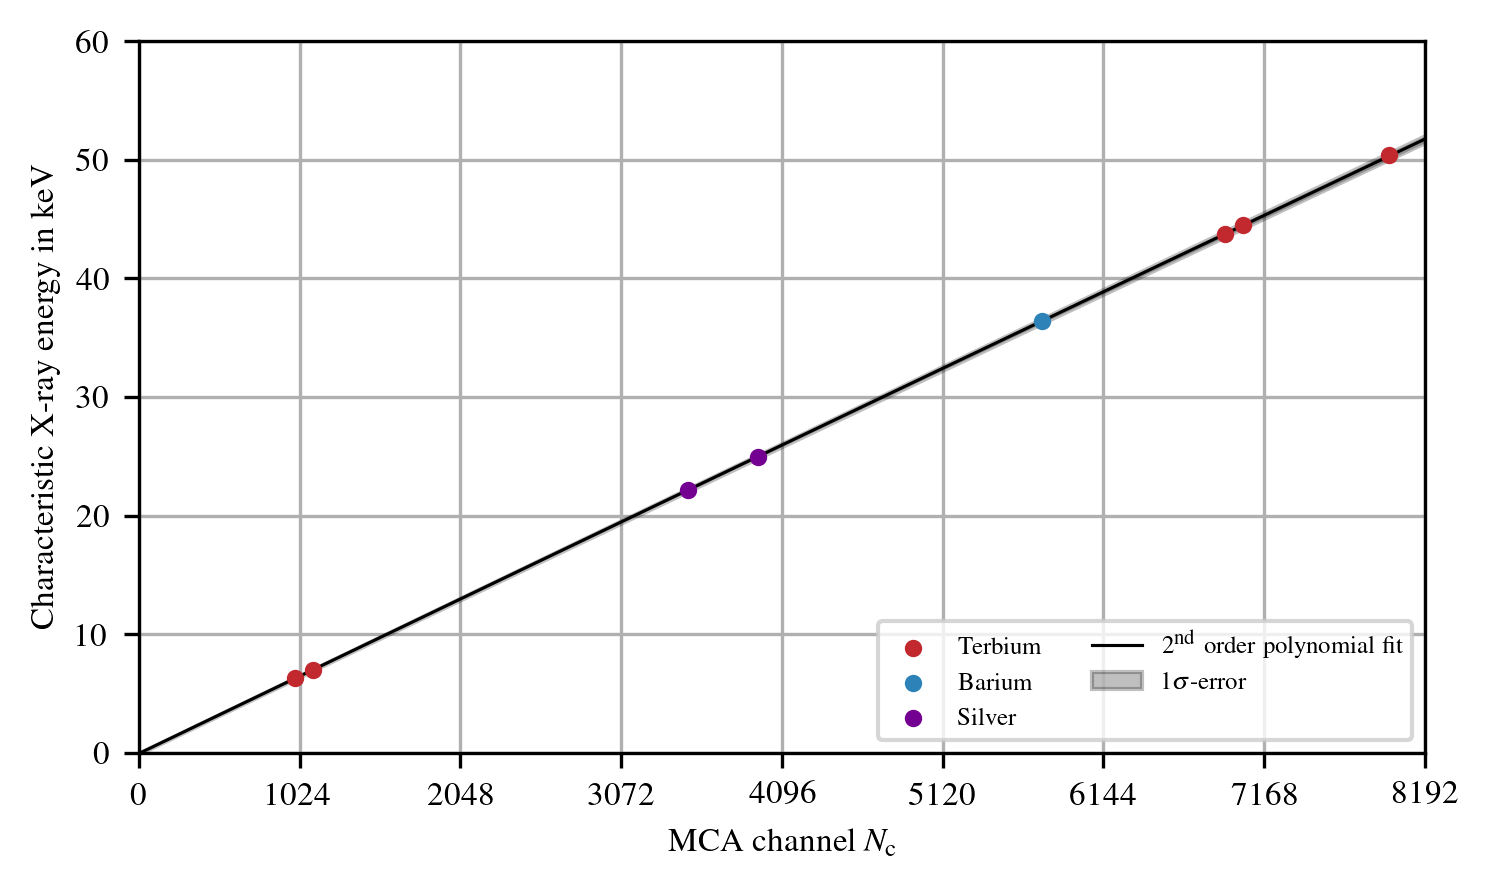

7

In [9]:
nameEnergyCal = 'MCA_8192-EG_4096-5cm'
measurementDate = '2026_02_27'
EnergyCal_1(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

## Energy Calibrations


### MCA = 8192 | Energy Gain = 2730 | 5cm

In [10]:
def EnergyCal_2(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Tb_lines = [43744.1, 44481.6, 50382]
    Ba_lines = [36378.2]
    Ag_lines = [22162.92, 24942.4]
    
    Tb_peaks_err = [1.488, 1.124, 2.428, 1.404, 1.441]
    Ba_peaks_err = [2.247]
    Ag_peaks_err = [0.615, 1.682]
    
    Tb_peaks = [4613.63, 4689.795, 5306.07] # KL2, KL3, KM3, LAlpha, LBeta
    Ba_peaks = [3833.776] #KM3
    Ag_peaks = [2331.335, 2630.052] #KL3, KM3
    
    lines,peaks,peaks_err = [],[],[]
    for e in [Tb_lines, Ba_lines, Ag_lines]:
        for i in e:
            lines.append(i)
    for e in [Tb_peaks_err, Ba_peaks_err, Ag_peaks_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Tb_peaks, Ba_peaks, Ag_peaks]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Tb_peaks, Tb_lines, s=10, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Terbium')# / 20260227-153740')
    ax.scatter(Ba_peaks, Ba_lines, s=10, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Barium')# / 20260227-152912')
    ax.scatter(Ag_peaks, Ag_lines, s=10, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Silver')# / 20260227-152010')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,60000)
    ax.set_yticks([0,10000,20000,30000,40000,50000,60000],[0,10,20,30,40,50,60])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return 7


[43744.1, 44481.6, 50382, 36378.2, 22162.92, 24942.4]
PARAMS: [2.88048523e+02 9.33668259e+00 1.86960366e-05]
UNCERT: [1.70812409e+02 1.00425020e-01 1.37769551e-05]
{'param': array([2.88048523e+02, 9.33668259e+00, 1.86960366e-05]), 'errors': array([1.70812409e+02, 1.00425020e-01, 1.37769551e-05])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


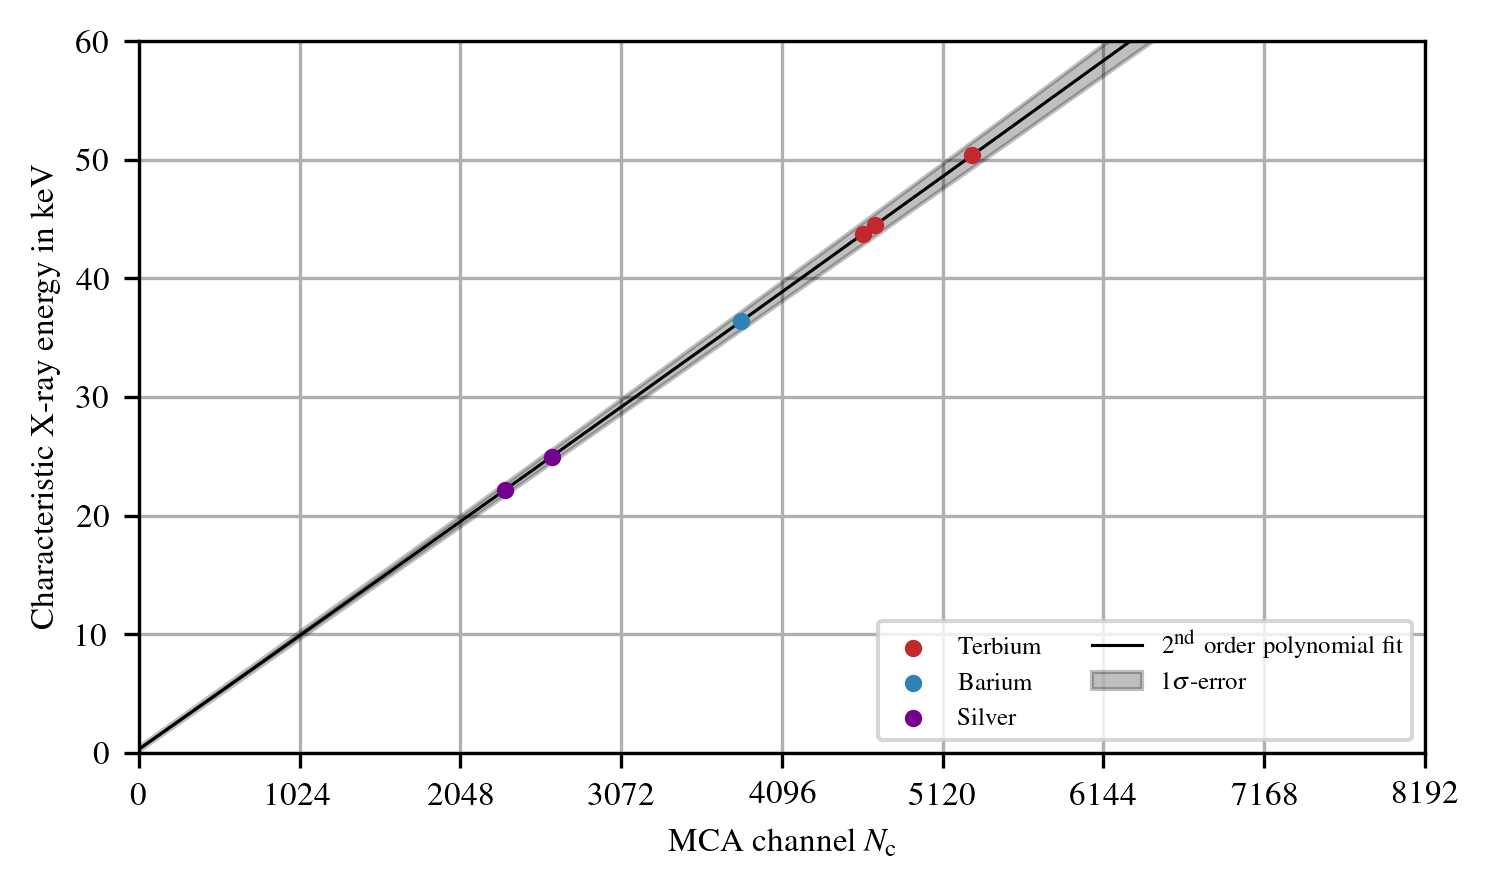

7

In [11]:
nameEnergyCal = 'MCA_8192-EG_2730-5cm'
measurementDate = '2026_02_27'
EnergyCal_2(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

## Energy Calibrations


### MCA = 8192 | Energy Gain = 10922

In [ ]:
def EnergyCal_3(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Cu_lines = [8046.3,8903.9] # Ka1,Kb1
    Rb_lines = [13396.0,14960.9,15087.0] #Ka1 Kb1 Kb2/Kb5???
    Mo_lines = [17480.0]
    
    Cu_peaks_err = [0.429,3.601]
    Rb_peaks_err = [0.407,1.815,0.998]
    Mo_peaks_err = [0.363]
    
    Cu_peaks = [3397.287,3764.867]
    Rb_peaks = [5648.343,6297.683,6336.138]
    Mo_peaks = [7363.273]
    
    lines,peaks,peaks_err = [],[],[]
    for e in [Cu_lines, Rb_lines, Mo_lines]:
        for i in e:
            lines.append(i)
    for e in [Cu_peaks_err, Rb_peaks_err, Mo_peaks_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Cu_peaks, Rb_peaks, Mo_peaks]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Cu_peaks, Cu_lines, s=10, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Terbium')# / 20260227-153740')
    ax.scatter(Rb_peaks, Rb_lines, s=10, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Rubidium')# / 20260227-152912')
    ax.scatter(Mo_peaks, Mo_lines, s=10, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Molybdenum')# / 20260227-152010')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,20000)
    ax.set_yticks([0,5000,10000,15000,20000],[0,5,10,15,20])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return 7

[8046.3, 8903.9, 13396.0, 14960.9, 15087.0, 17480.0]
PARAMS: [-6.89126838e+01  2.39209863e+00 -1.12342429e-06]
UNCERT: [1.25541833e+02 5.02303118e-02 4.68058452e-06]
{'param': array([-6.89126838e+01,  2.39209863e+00, -1.12342429e-06]), 'errors': array([1.25541833e+02, 5.02303118e-02, 4.68058452e-06])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


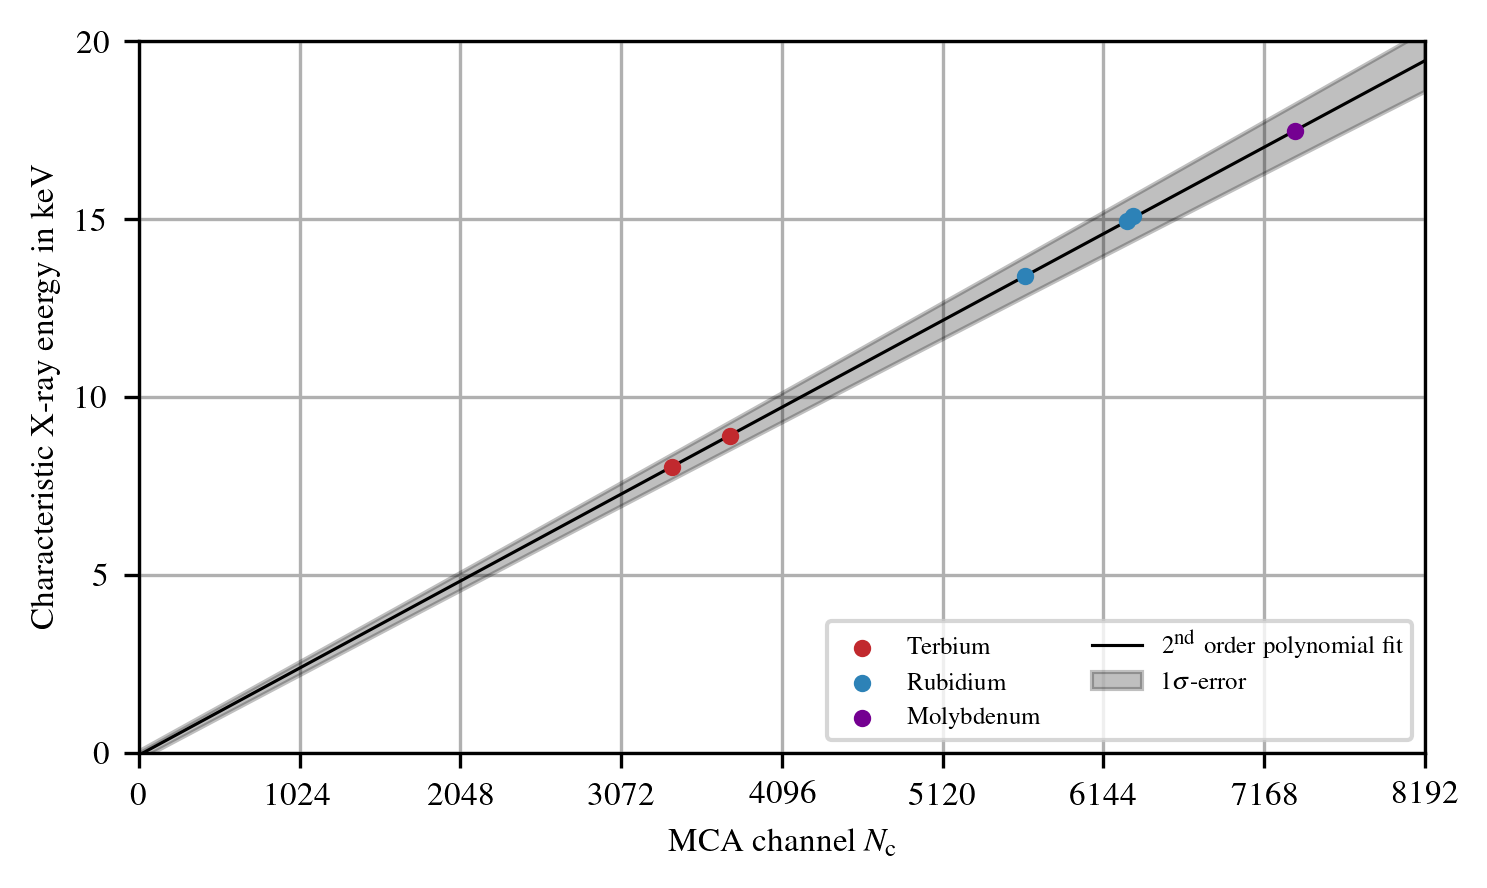

7

In [23]:
nameEnergyCal = 'MCA_8192-EG_10922'
measurementDate = '2026_02_27'
EnergyCal_3(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

## Overview

In [31]:
def low_lin(param, error, x):
    return (param[0] - error[0]) + (param[1] - error[1])*x + (param[2] - error[2])*x**2

def high_lin(param, error, x):
    return (param[0] + error[0]) + (param[1] + error[1])*x + (param[2] + error[2])*x**2

In [40]:
def EnergyCal_Overview(data:dict):
    DPI = 300
    fig, ax = plt.subplots(figsize=(7,6), dpi = DPI)
    ins = ax.inset_axes([0.1,0.55,0.2,0.2])
    xlin = np.linspace(0,8192,8192)
    
    ax.scatter([],[],alpha=0, label='MCA channel width:')
    
    for s in ['2','1','3']:
        dataset = data[s]
        ax.plot(xlin, energy_func(dataset['param'], xlin), lw = 1, label=f'Manufacturer: {dataset['E_ketek']} eV / Energy Calibration: {round(dataset['param'][1],3)} eV', zorder=2)
        ax.fill_between(xlin,low_lin(dataset['param'],dataset['paramUn'],xlin),high_lin(dataset['param'],dataset['paramUn'],xlin), color='black', alpha=0.4, zorder=2)
        ins.plot(xlin, energy_func(dataset['param'], xlin), lw = 1, label=f'Manufacturer: {dataset['E_ketek']} eV / Energy Calibration: {round(dataset['param'][1],3)} eV', zorder=2)
        # ins.fill_between(xlin,low_lin(dataset['param'],dataset['paramUn'],xlin),high_lin(dataset['param'],dataset['paramUn'],xlin), color='black', alpha=0.4, zorder=2)
    
    
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_yscale('linear')
    ax.set_ylim(10,80e3)
    
    ax.set_xlabel('MCA')
    ax.set_ylabel('Energy / keV')
    
    ax.set_yticks([10,10000,20000,30000,40000,50000,60000,70000,80000],[0,10,20,30,40,50,60,70,80])
    ax.grid(zorder=1)
    
    ins.set_xlim(0,5)
    ins.set_ylim(-100,350)
    ins.grid(zorder=1)
    ins.set_ylabel('Energy / eV')
    ins.set_xlabel('MCA')
    
    
    plt.legend()
    
    plt.savefig(f'./energy_cali/Comparison_180326.png', dpi=DPI)
    plt.savefig(f'./energy_cali/Comparison_180326.pdf', dpi=DPI)
    
    plt.show()

1.0459463697663478 1.071007818357074 1.0451505016722409


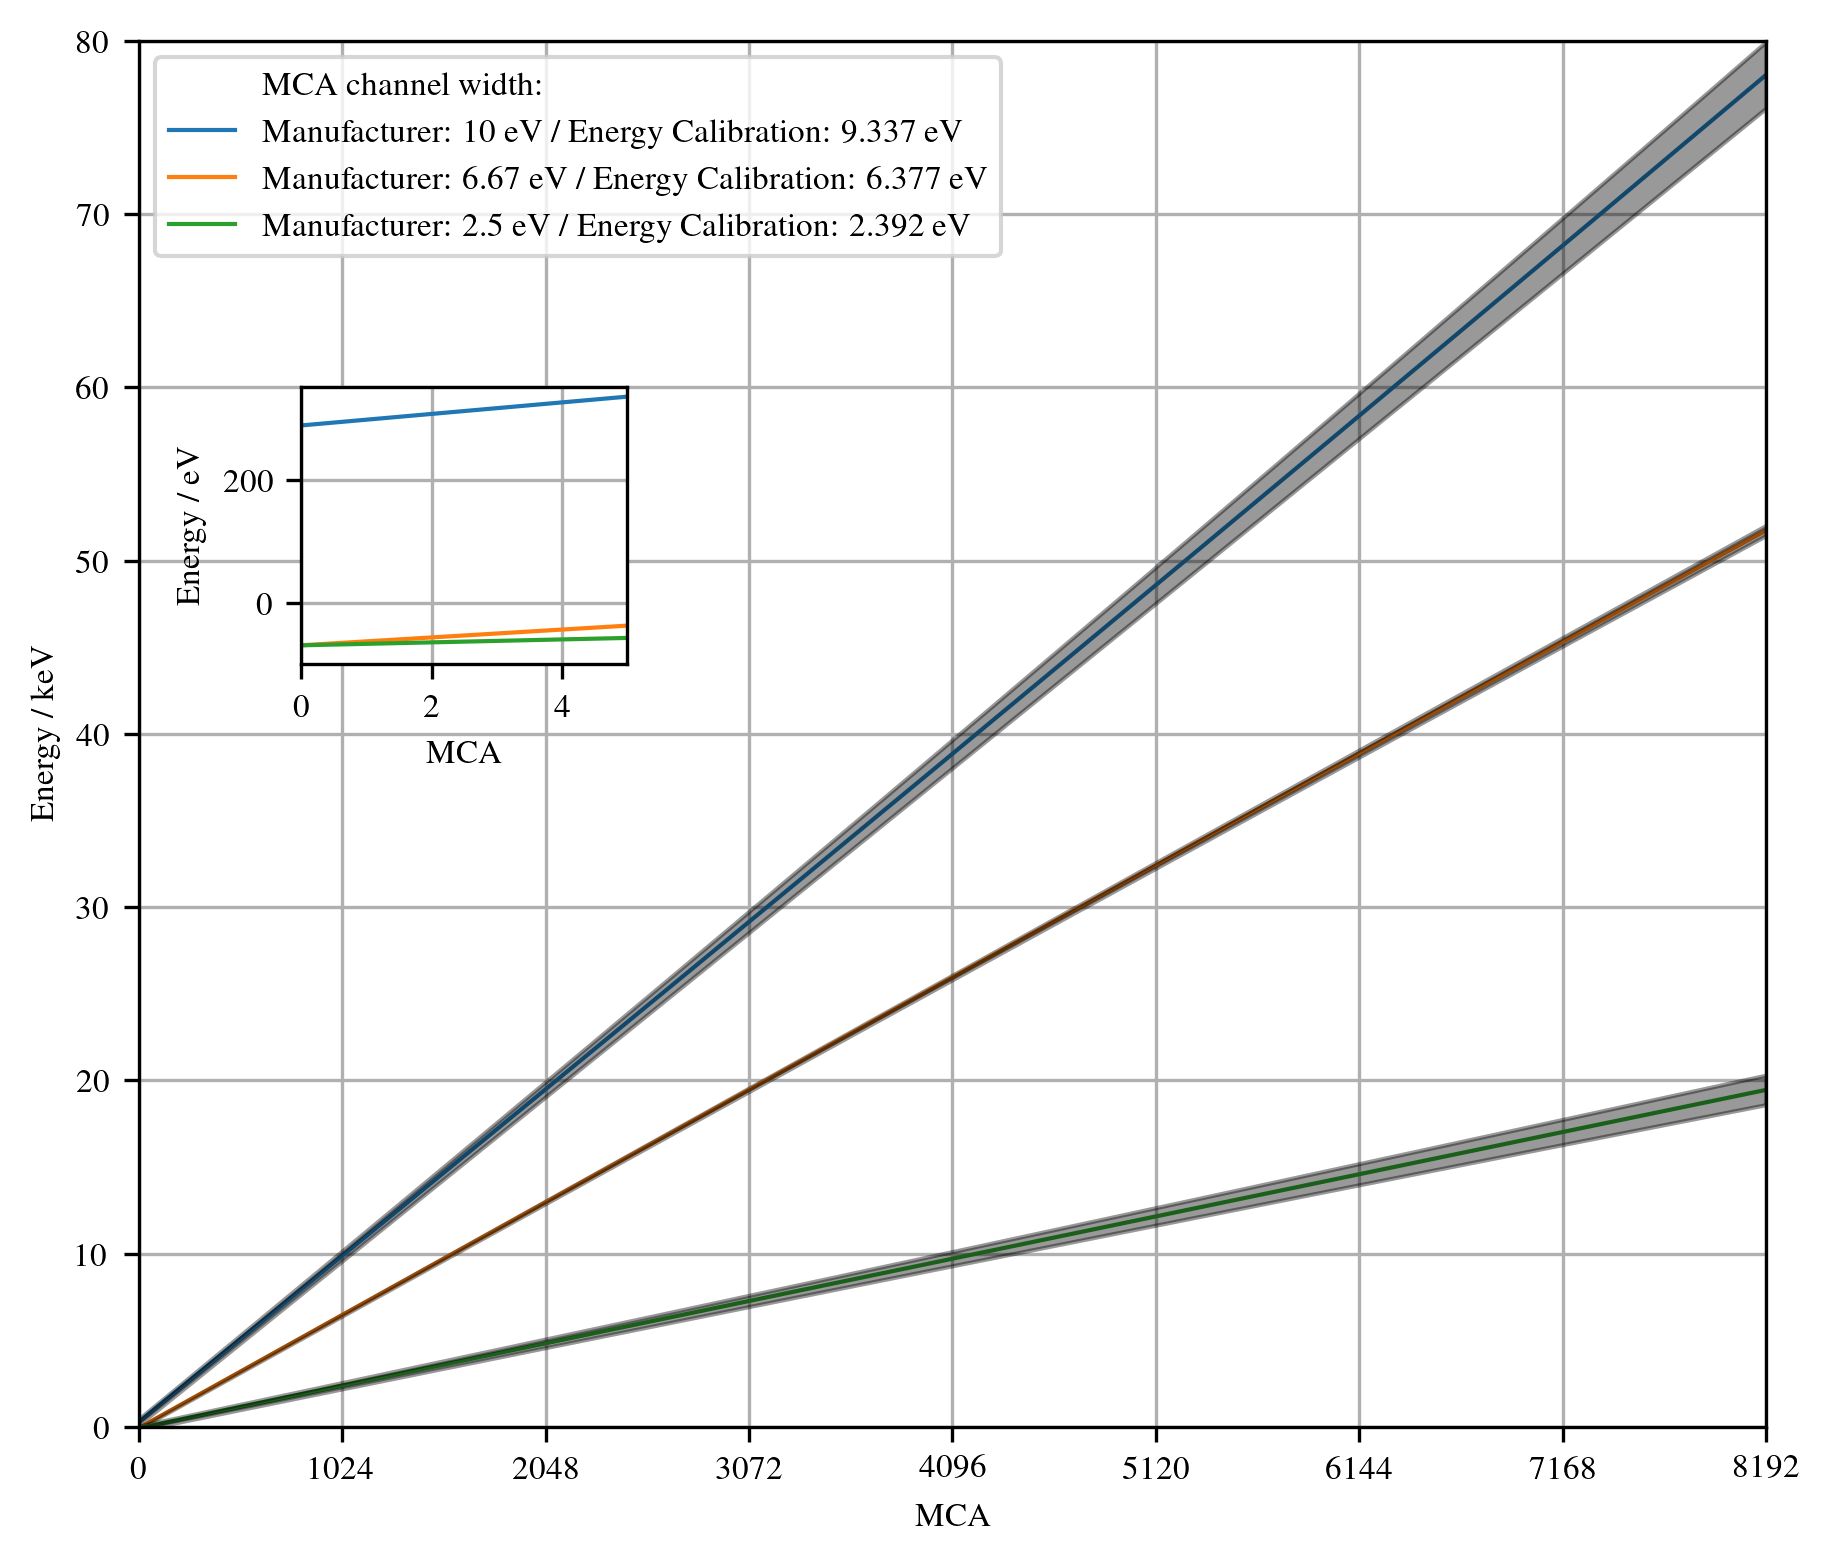

In [41]:
energy_data = {'1':{'MCA':8192, 
                    'EG':4096,
                    'E_ketek':6.67, 
                    'param':[-6.88746563e+01,6.37653023e+00,-6.36631343e-06],
                    'paramUn':[3.32604745e+01,1.63410621e-02,1.84015727e-06]},
               '2':{'MCA':8192, 
                    'EG':2730,
                    'E_ketek':10,
                    'param':[2.88048523e+02,9.33668259e+00,1.86960366e-05],
                    'paramUn':[1.70812409e+02,1.00425020e-01,1.37769551e-05]},
               '3':{'MCA':8192, 
                    'EG':10922,
                    'E_ketek':2.5,
                    'param':[-6.89126838e+01,2.39209863e+00,-1.12342429e-06],
                    'paramUn':[1.25541833e+02,5.02303118e-02,4.68058452e-06]}}

print(6.67/6.377, 10/9.337, 2.5/2.392)
EnergyCal_Overview(data=energy_data)

### To-Do
- Include measurement points in comparison plot

# Set B + D

## MCA 8192 | EG 10922

In [6]:
def EnergyCal_8192_10922(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Cu_lines_B = [8046.3,8903.9] # Ka1,Kb1
    Cu_lines_D = [8046.3,8903.9] # Ka1,Kb1
    Rb_lines_B = [13396.0,14960.9,15087.0] #Ka1 Kb1 Kb2/Kb5???
    Rb_lines_D = [13396.0,14960.9,15087.0] #Ka1 Kb1 Kb2/Kb5???
    Mo_lines_B = [17480.0]
    
    Cu_MCA_B = [3397.287,3764.867]
    Cu_MCA_D = [3398.418,3761.303]
    Rb_MCA_B = [5648.343,6297.683,6336.138]
    Rb_MCA_D = [5647.762,6316.506,6420.072]
    Mo_MCA_B = [7363.273]
    
    Cu_MCA_B_err = [0.429,3.601]
    Cu_MCA_D_err = [1.074,2.275]
    Rb_MCA_B_err = [0.407,1.815,0.998]
    Rb_MCA_D_err = [1.047,3.805,22.512]
    Mo_MCA_B_err = [0.363]
    
    lines,peaks,peaks_err = [],[],[]
    for e in [Cu_lines_B, Cu_lines_D, Rb_lines_B, Rb_lines_D, Mo_lines_B]:
        for i in e:
            lines.append(i)
    for e in [Cu_MCA_B_err, Cu_MCA_D_err, Rb_MCA_B_err, Rb_MCA_D_err, Mo_MCA_B_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Cu_MCA_B, Cu_MCA_D, Rb_MCA_B, Rb_MCA_D, Mo_MCA_B]:
        for i in e:
            peaks.append(i)
    # print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Cu_MCA_B, Cu_lines_B, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Copper / 20260227-153740')
    ax.scatter(Rb_MCA_B, Rb_lines_B, s=10, marker='*', lw=0.5, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Rubidium / 20260227-152912')
    ax.scatter(Mo_MCA_B, Mo_lines_B, s=10, marker='h', lw=0.1, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Molybdenum / 20260227-152010')
    ax.scatter(Cu_MCA_D, Cu_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_five'][0], zorder=3, label=f'Copper / 20260325-070325')
    ax.scatter(Rb_MCA_D, Rb_lines_D, s=10, marker='*', lw=0.5, color=color_schemes['c_five'][4], zorder=3, label=f'Rubidium / 20260325-081734')
    # ax.scatter(Mo_MCA_D, Mo_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Molybdenum / 20260227-152010')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,20000)
    ax.set_yticks([0,5000,10000,15000,20000],[0,5,10,15,20])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return lines, peaks, peaks_err, beta_export

## MCA 8192 | EG 5461

In [8]:
def EnergyCal_8192_5461(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Cu_lines_B = [8046.3,8903.9] # Ka1,Kb1
    
    Rb_lines_B = [13396.0,14960.9] #Ka1 Kb1
    
    Mo_lines_B = [17480.0]
    Mo_lines_D = [17480.0,19606.0,19962.4] #Ka1 Kb1 Kb2
    
    Ag_lines_D = [22163.0, 24941.0, 25450.3, 2982.7, 3150.0] #Ka1 Kb1 Kb2 La1
    #------------------------------------------------------------------------
    
    Cu_MCA_B = [1698.362,1880.149]
    
    Rb_MCA_B = [2824.202,3159.380]
    
    Mo_MCA_B = [3681.346]
    Mo_MCA_D = [3681.676,4135.527,4214.037]
    
    Ag_MCA_D = [4663.883,5260.147,5370.210,631.999,661.308]#?
    #------------------------------------------------------------------------
    
    Cu_MCA_B_err = [0.369,1.277]
    
    Rb_MCA_B_err = [0.193,0.535]
    
    Mo_MCA_B_err = [0.233]
    Mo_MCA_D_err = [1.964,5.656,9.357]
    
    Ag_MCA_D_err = [1.736,4.652,6.518,10.201,12.279]#?
    
    lines,peaks,peaks_err = [],[],[]
    for e in [Cu_lines_B, Rb_lines_B, Mo_lines_B, Mo_lines_D, Ag_lines_D]:
        for i in e:
            lines.append(i)
    for e in [Cu_MCA_B_err, Rb_MCA_B_err, Mo_MCA_B_err, Mo_MCA_D_err, Ag_MCA_D_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Cu_MCA_B, Rb_MCA_B, Mo_MCA_B, Mo_MCA_D, Ag_MCA_D]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Cu_MCA_B, Cu_lines_B, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Copper / 20260227-150015')
    ax.scatter(Rb_MCA_B, Rb_lines_B, s=10, marker='*', lw=0.5, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Rubidium / 20260227-133248')
    ax.scatter(Mo_MCA_B, Mo_lines_B, s=10, marker='h', lw=0.1, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Molybdenum / 20260227-134506')
    
    # ax.scatter(Cu_MCA_D, Cu_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_five'][0], zorder=3, label=f'Copper / 20260325-070325')
    # ax.scatter(Rb_MCA_D, Rb_lines_D, s=10, marker='*', lw=0.5, color=color_schemes['c_five'][4], zorder=3, label=f'Rubidium / 20260325-081734')
    ax.scatter(Ag_MCA_D, Ag_lines_D, s=10, marker='^', lw=0.1, color=color_schemes['c_rainbow'][2], zorder=3, label=f'Silver / 20260325-102428')
    ax.scatter(Mo_MCA_D, Mo_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Molybdenum / 20260325-092112')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,40000)
    ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000],[0,5,10,15,20,25,30,35,40])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return lines, peaks, peaks_err, beta_export

## MCA 8192 | EG 4096

In [9]:
def EnergyCal_8192_4096(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Mo_lines_B = [17480.0,19606.0,19962.4] #Ka1 Kb1 Kb2
    
    Ag_lines_B = [21990.0,22163.0,24910.2,24941.0,25450.3] #Ka1 Ka2 Kb1 Kb3 Kb2
    
    Ba_lines_B = [32194.0] #Ka1 Kb1
    Ba_lines_D = [32194.0,31817.0,36378.0,4466.5,4828.3] #Ka2 Ka1 Kb1 Kb2 La1 Lb1
    
    Tb_lines_B = [43744.1,44482.0,50385.0,6272.9,6975.1,7097.0] #Ka2 Ka1 Kb1 La1 Lb1 Lb3
    #------------------------------------------------------------------------
    
    Mo_MCA_B = [2760.711,3102.117,3157.109]
    
    Ag_MCA_B = [3497.830,3497.830,3944.661,3944.661,4027.031]
    
    Ba_MCA_B = [5078.808]
    Ba_MCA_D = [5095.426,5033.288,5752.193,709.322,760]
    
    Tb_MCA_B = [6919.627,7037.031,7956.794,993.411,1104.716,1159.418]
    #------------------------------------------------------------------------
    
    Mo_MCA_B_err = [0.325,1.411,8.121]
    
    Ag_MCA_B_err = [0.354,0.354,1.391,1.391,7.882]
    
    Ba_MCA_B_err = [2.505]
    Ba_MCA_D_err = [4.442,5.850,1.910,2.221,10.000]
    
    Tb_MCA_B_err = [2.285,1.499,8.485,1.211,0.856,3.617]
    
    #------------------------------------------------------------------------
    lines,peaks,peaks_err = [],[],[]
    for e in [Mo_lines_B, Ag_lines_B, Ba_lines_B, Ba_lines_D, Tb_lines_B]:
        for i in e:
            lines.append(i)
    for e in [Mo_MCA_B_err, Ag_MCA_B_err, Ba_MCA_B_err, Ba_MCA_D_err, Tb_MCA_B_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Mo_MCA_B, Ag_MCA_B, Ba_MCA_B, Ba_MCA_D, Tb_MCA_B]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Mo_MCA_B, Mo_lines_B, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Molybdenum / 20260227-144952')
    ax.scatter(Ag_MCA_B, Ag_lines_B, s=10, marker='*', lw=0.5, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Silver / 20260227-143657')
    ax.scatter(Ba_MCA_B, Ba_lines_B, s=10, marker='h', lw=0.1, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Barium / 20260227-142643')
    ax.scatter(Tb_MCA_B, Tb_lines_B, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][2], zorder=3, label=f'Terbium / 20260227-144113')
    
    # ax.scatter(Cu_MCA_D, Cu_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_five'][0], zorder=3, label=f'Copper / 20260325-070325')
    # ax.scatter(Rb_MCA_D, Rb_lines_D, s=10, marker='*', lw=0.5, color=color_schemes['c_five'][4], zorder=3, label=f'Rubidium / 20260325-081734')
    # ax.scatter(Ag_MCA_D, Ag_lines_D, s=10, marker='^', lw=0.1, color=color_schemes['c_rainbow'][2], zorder=3, label=f'Silver / 20260325-102428')
    ax.scatter(Ba_MCA_D, Ba_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][3], zorder=3, label=f'Barium / 20260325-121419')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,55000)
    ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000,45000,50000,55000],[0,5,10,15,20,25,30,35,40,45,50,55])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return lines, peaks, peaks_err, beta_export

In [10]:
def EnergyCal_8192_3770(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Tb_lines_D = [43744.1,44482.0,50385.0,51673.6,6272.9,6975.1,7097.0] #Ka2 Ka1 Kb1 Kb2 La1 Lb1 Lb3
    #------------------------------------------------------------------------
    Tb_MCA_D = [6368.913,6478.491,7326.723,7527.786,914.324,1015.343,1077.617]
    #------------------------------------------------------------------------
    Tb_MCA_D_err = [3.259,3.025,4.123,7.668,3.830,6.000,8.000]
    
    #------------------------------------------------------------------------
    lines,peaks,peaks_err = [],[],[]
    for e in [Tb_lines_D]:
        for i in e:
            lines.append(i)
    for e in [Tb_MCA_D_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Tb_MCA_D]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
        
    # ax.scatter(Cu_MCA_D, Cu_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_five'][0], zorder=3, label=f'Copper / 20260325-070325')
    # ax.scatter(Rb_MCA_D, Rb_lines_D, s=10, marker='*', lw=0.5, color=color_schemes['c_five'][4], zorder=3, label=f'Rubidium / 20260325-081734')
    # ax.scatter(Ag_MCA_D, Ag_lines_D, s=10, marker='^', lw=0.1, color=color_schemes['c_rainbow'][2], zorder=3, label=f'Silver / 20260325-102428')
    ax.scatter(Tb_MCA_D, Tb_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][2], zorder=3, label=f'Terbium / 20260325-132058')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,65000)
    ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000,45000,50000,55000,60000,65000],[0,5,10,15,20,25,30,35,40,45,50,55,60,65])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return lines, peaks, peaks_err, beta_export

In [11]:
def EnergyCal_8192_2730(nameEnergyCal:str, measurementDate:str):
    
    DPI = 300
            
    Mo_lines_B = [17375.0,17480.0,19588.0,19606.0,19962.4] #a2 Ka1 Kb3 Kb1 Kb2
    
    Ag_lines_B = [21990.0,22163.0,24910.2,24941.0,25450.3] #Ka1 Ka2 Kb1 Kb3 Kb2
    Ag_lines_D = [21990.0,22163.0,24910.2,24941.0,25450.3] #Ka1 Ka2 Kb1 Kb3 Kb2
    
    Ba_lines_B = [32194.0,31817.0] #Ka2 Ka1 Kb1
    Ba_lines_D = [32194.0,31817.0,36378.0] #Ka2 Ka1 Kb1 Kb2 La1 Lb1
    
    Tb_lines_B = [43744.1,44482.0,50385.0,6272.9,6975.1,7097.0] #Ka2 Ka1 Kb1 La1 Lb1 Lb3
    Tb_lines_D = [43744.1,44482.0,50385.0,51673.6,6272.9,6940.0,6975.1,8101.0,8423.9] #Ka2 Ka1 Kb1 La1 Lb1 Lb3
    #------------------------------------------------------------------------
    
    Mo_MCA_B = [1840.661,1840.661,2068.669,2068.669,2105.122]
    
    Ag_MCA_B = [2331.421,2331.421,2630.642,2630.642,2686.159]
    Ag_MCA_D = [2331.339,2331.339,2629.545,2629.545,2683.570]
    
    Ba_MCA_B = [3347.507,3394.432]
    Ba_MCA_D = [3355.232,3394.532,3833.776]
    
    Tb_MCA_B = [4612.222,4689.291,5305.900,662.584,738.160,778.033]
    Tb_MCA_D = [4613.630,4689.795,5306.071,5452.319,662.848,738.750,777.579,853.247,890.446]
    #------------------------------------------------------------------------
    
    Mo_MCA_B_err = [0.332,0.332,1.228,1.228,7.595]
    
    Ag_MCA_B_err = [0.351,0.351,2.449,2.449,1.252]
    Ag_MCA_D_err = [0.615,0.615,1.737,1.737,3.054]
    
    Ba_MCA_B_err = [2.150,2.160]
    Ba_MCA_D_err = [2.082,1.430,2.247]
    
    Tb_MCA_B_err = [1.257,2.104,4.590,1.089,0.856,2.968]
    Tb_MCA_D_err = [1.488,1.124,2.419,4.728,1.529,1.501,2.142,2.568,10.396]
    
    #------------------------------------------------------------------------
    lines,peaks,peaks_err = [],[],[]
    for e in [Mo_lines_B, Ag_lines_B, Ag_lines_D, Ba_lines_B, Ba_lines_D, Tb_lines_B, Tb_lines_D]:
        for i in e:
            lines.append(i)
    for e in [Mo_MCA_B_err, Ag_MCA_B_err, Ag_MCA_D_err, Ba_MCA_B_err, Ba_MCA_D_err, Tb_MCA_B_err, Tb_MCA_D_err]:
        for i in e:
            peaks_err.append(i)
    for e in [Mo_MCA_B, Ag_MCA_B, Ag_MCA_D, Ba_MCA_B, Ba_MCA_D, Tb_MCA_B, Tb_MCA_D]:
        for i in e:
            peaks.append(i)
    print(lines)
    init_values = [100,8,0]
    beta= peak_fitter(lines=lines, peaks=peaks, peaks_err=peaks_err, init_values=init_values)
    print(beta)
    beta_export = [beta['param'],beta['errors']]
    print('ENERGY CALIBRATION: Fit done.')
    
    csv_file_name = f'./energy_cali/{measurementDate}_{nameEnergyCal}.csv'
        
    with open(csv_file_name, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerows(beta_export)
    print('ENERGY CALIBRATION: csv done.')
    
    fig, ax = plt.subplots(figsize=(5,3), dpi=DPI)
    ax.scatter(Mo_MCA_B, Mo_lines_B, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][1], zorder=3, label=f'Molybdenum / 20260227-144952')
    ax.scatter(Ag_MCA_B, Ag_lines_B, s=10, marker='*', lw=0.5, color=color_schemes['c_rainbow'][6], zorder=3, label=f'Silver / 20260227-143657')
    ax.scatter(Ba_MCA_B, Ba_lines_B, s=10, marker='h', lw=0.1, color=color_schemes['c_rainbow'][7], zorder=3, label=f'Barium / 20260227-142643')
    ax.scatter(Tb_MCA_B, Tb_lines_B, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][2], zorder=3, label=f'Terbium / 20260227-144113')
    
    # ax.scatter(Cu_MCA_D, Cu_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_five'][0], zorder=3, label=f'Copper / 20260325-070325')
    # ax.scatter(Rb_MCA_D, Rb_lines_D, s=10, marker='*', lw=0.5, color=color_schemes['c_five'][4], zorder=3, label=f'Rubidium / 20260325-081734')
    ax.scatter(Ag_MCA_D, Ag_lines_D, s=10, marker='^', lw=0.1, color=color_schemes['c_rainbow'][5], zorder=3, label=f'Silver / 20260227-102428')
    ax.scatter(Ba_MCA_D, Ba_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][3], zorder=3, label=f'Barium / 20260227-121419')
    ax.scatter(Tb_MCA_D, Tb_lines_D, s=10, marker='s', lw=0.1, color=color_schemes['c_rainbow'][4], zorder=3, label=f'Terbium / 20260227-154148')
    
    xlin = np.linspace(0,8192,8192)
    ax.plot(xlin, energy_func(beta_export[0],xlin), color='black', lw=0.75, label=r'$2^{\mathrm{nd}}$ order polynomial fit', zorder=2)
    # ax.plot([],[],alpha=0,label=r'$E(N_{\mathrm{c}}) = -68.87 + 6.377\cdot N_{\mathrm{c}} - 6.366\cdot 10^{-6}\cdot N_{\mathrm{c}}^2$')
    ax.fill_between(xlin,lowerLim(beta_export,xlin),upperLim(beta_export,xlin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')
        
    ax.set_xlabel(r'MCA channel $N_{\mathrm{c}}$')
    ax.set_ylabel('Characteristic X-ray energy in keV')
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_ylim(0,80000)
    ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000,45000,50000,55000,60000,65000,70000,75000,80000],[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80])
    
    plt.legend(loc = 4, fontsize=6, ncol=2)
    plt.grid(which='both')
    plt.tight_layout()
    
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.png', dpi=DPI)
    plt.savefig(f'./energy_cali/{measurementDate}_{nameEnergyCal}.pdf', dpi=DPI)
    print('ENERGY CALIBRATION: Figures done.')
    
    plt.show()
    return lines, peaks, peaks_err, beta_export

### All Calibrations

PARAMS: [-5.68691915e+01  2.38663453e+00 -6.03489536e-07]
UNCERT: [7.30253132e+01 2.94333222e-02 2.76395064e-06]
{'param': array([-5.68691915e+01,  2.38663453e+00, -6.03489536e-07]), 'errors': array([7.30253132e+01, 2.94333222e-02, 2.76395064e-06])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


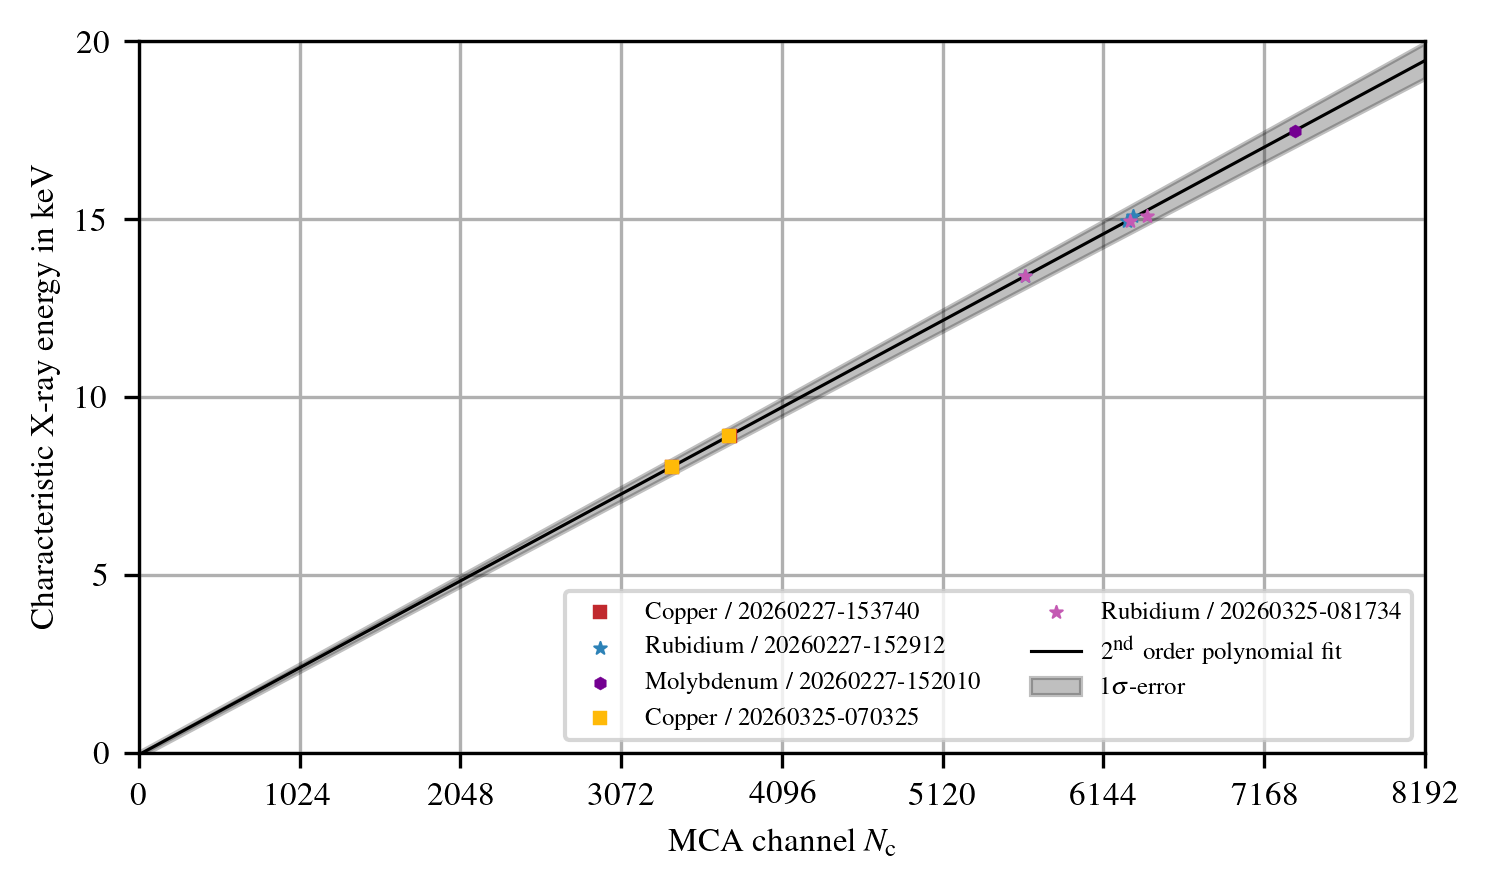

[8046.3, 8903.9, 13396.0, 14960.9, 17480.0, 17480.0, 19606.0, 19962.4, 22163.0, 24941.0, 25450.3, 2982.7, 3150.0]
PARAMS: [4.73072542e+00 4.72470711e+00 5.65721290e-06]
UNCERT: [3.89396734e+01 2.84661329e-02 5.02722261e-06]
{'param': array([4.73072542e+00, 4.72470711e+00, 5.65721290e-06]), 'errors': array([3.89396734e+01, 2.84661329e-02, 5.02722261e-06])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


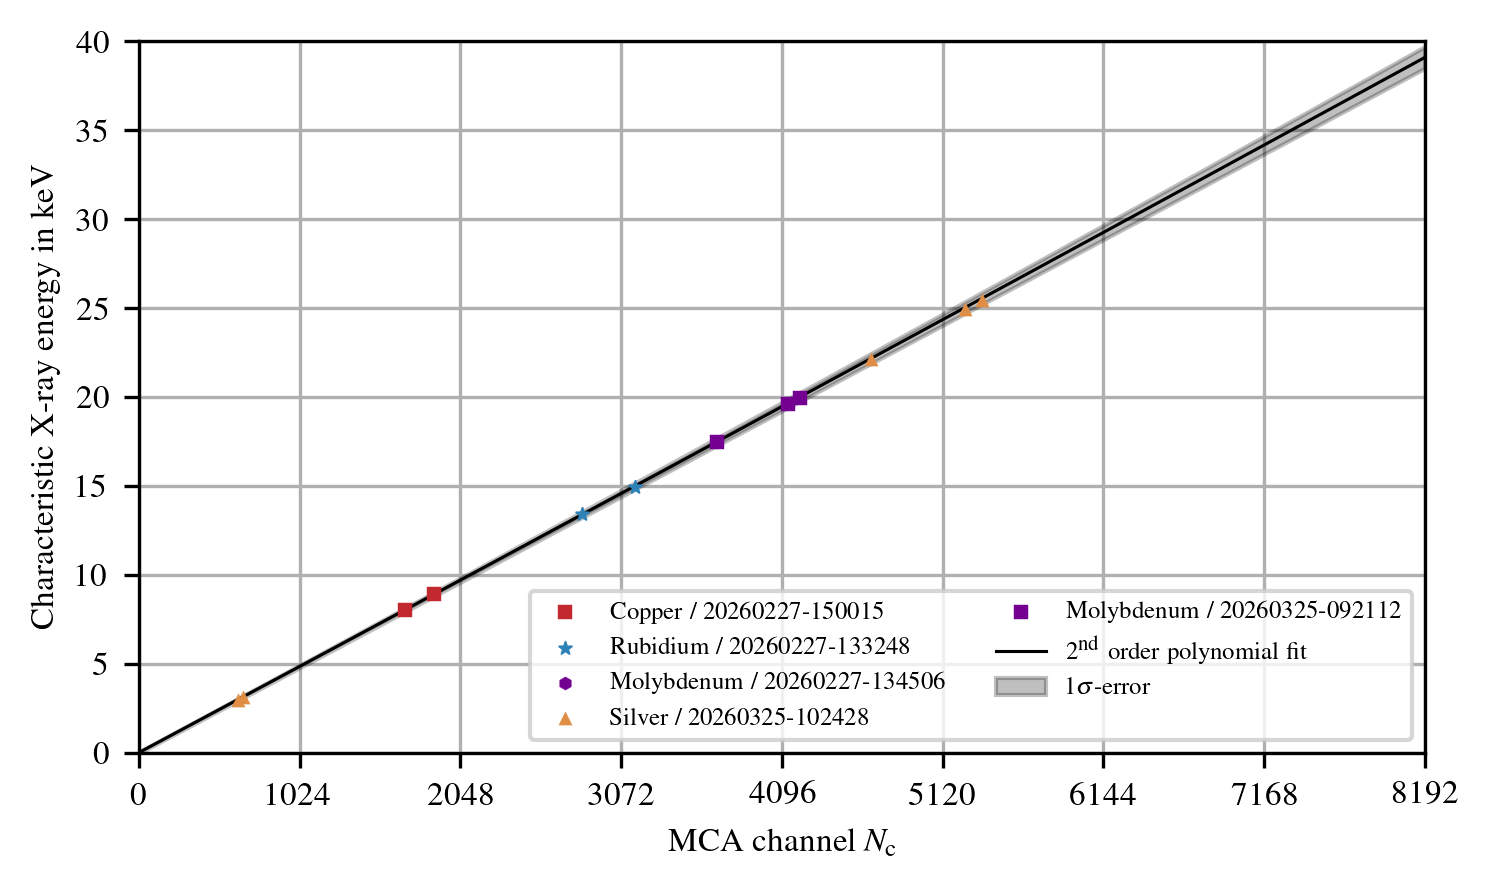

[17480.0, 19606.0, 19962.4, 21990.0, 22163.0, 24910.2, 24941.0, 25450.3, 32194.0, 32194.0, 31817.0, 36378.0, 4466.5, 4828.3, 43744.1, 44482.0, 50385.0, 6272.9, 6975.1, 7097.0]
PARAMS: [2.25654278e+01 6.30498969e+00 1.72447004e-06]
UNCERT: [9.51286821e+01 5.01824244e-02 6.63489116e-06]
{'param': array([2.25654278e+01, 6.30498969e+00, 1.72447004e-06]), 'errors': array([9.51286821e+01, 5.01824244e-02, 6.63489116e-06])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


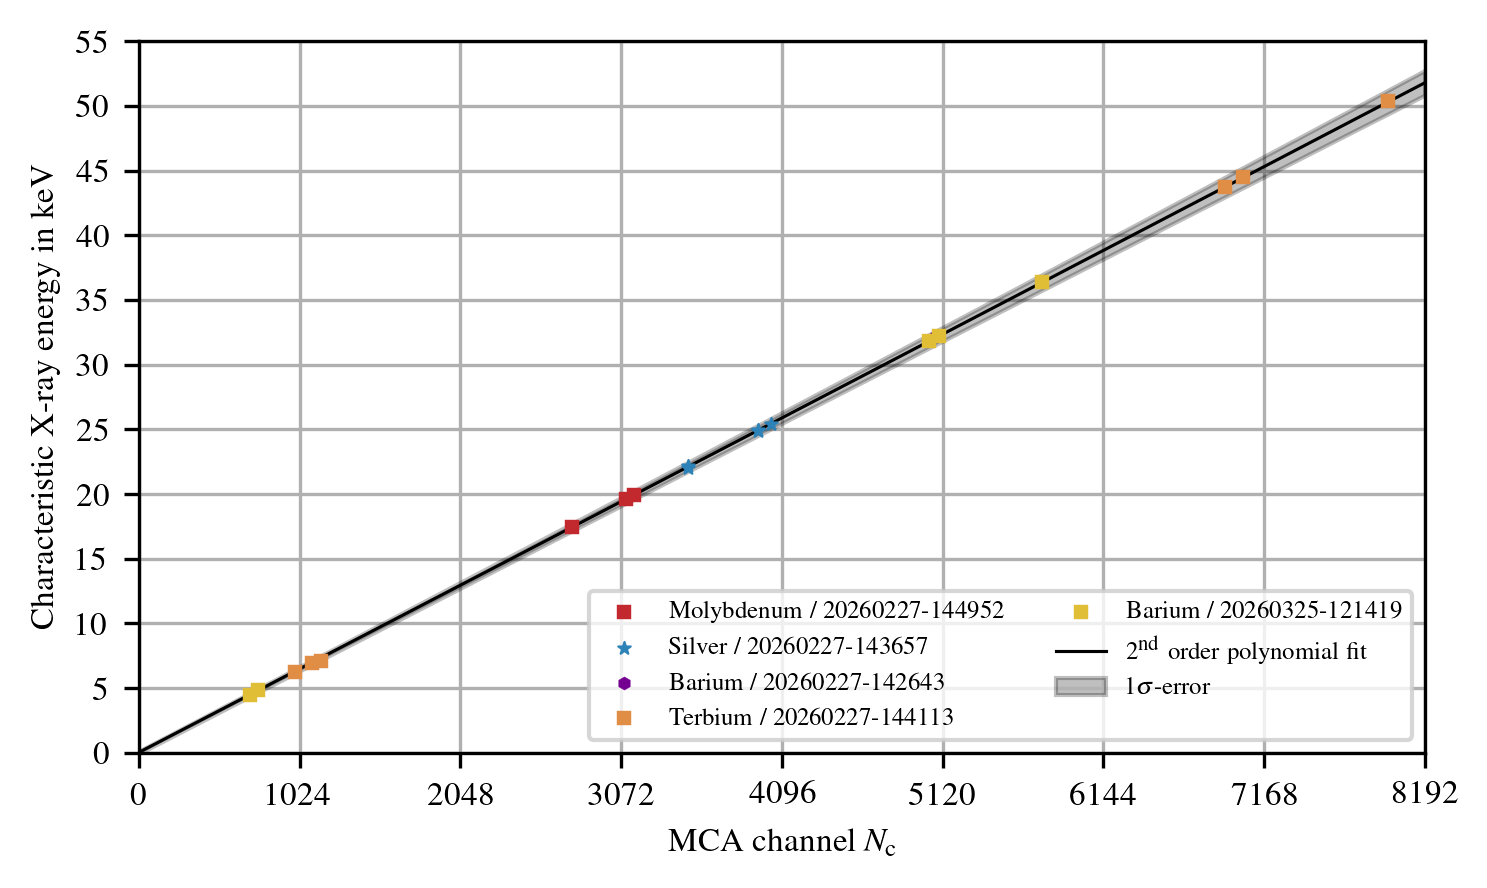

[43744.1, 44482.0, 50385.0, 51673.6, 6272.9, 6975.1, 7097.0]
PARAMS: [-9.66882811e+00  6.82434864e+00  6.89052537e-06]
UNCERT: [1.14656774e+02 1.06265066e-01 1.35645186e-05]
{'param': array([-9.66882811e+00,  6.82434864e+00,  6.89052537e-06]), 'errors': array([1.14656774e+02, 1.06265066e-01, 1.35645186e-05])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


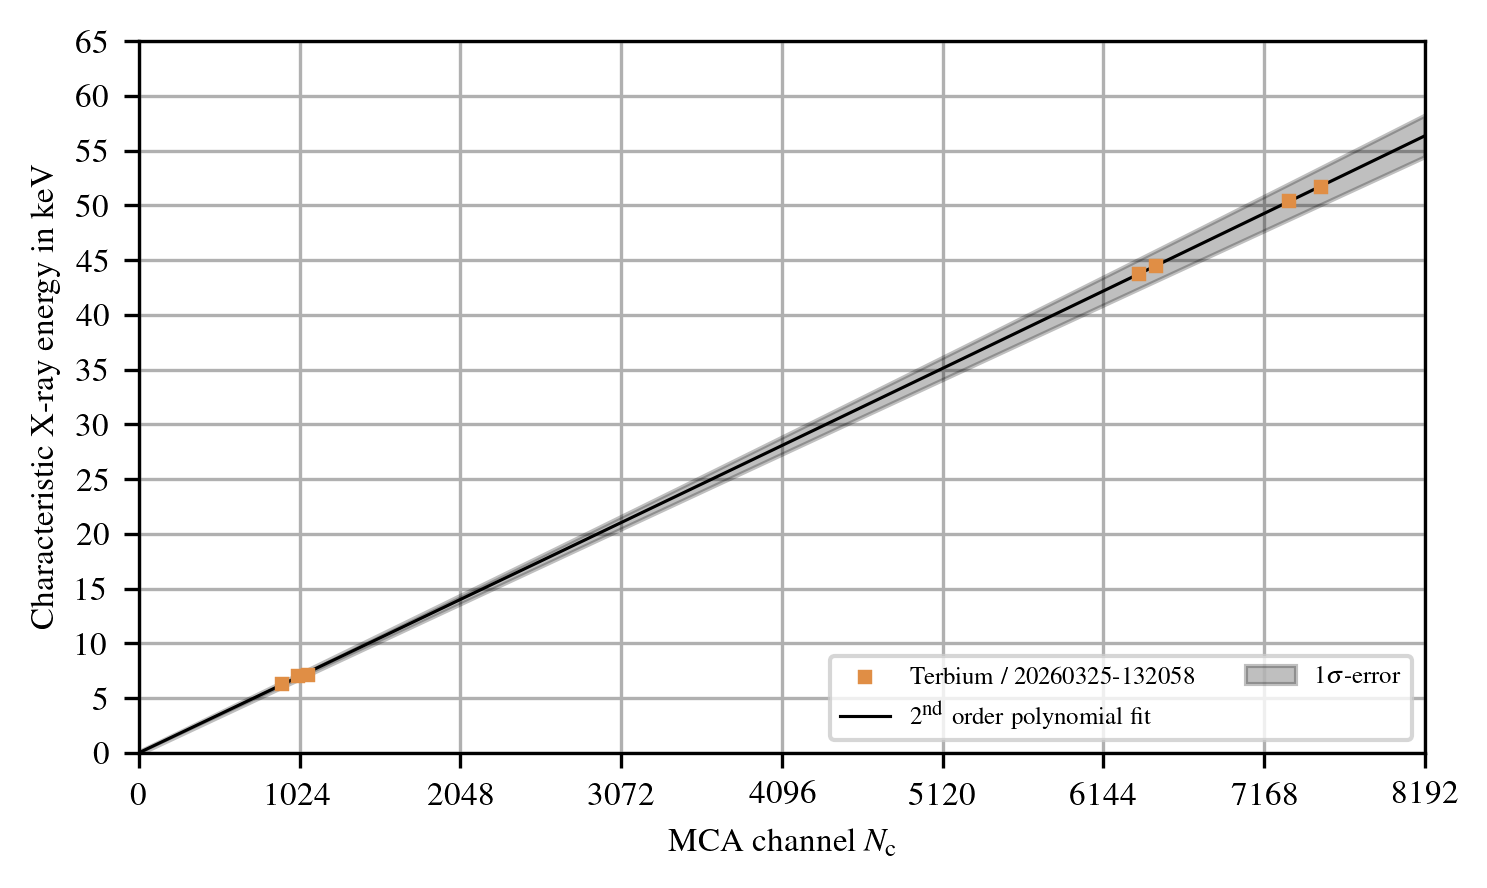

[17375.0, 17480.0, 19588.0, 19606.0, 19962.4, 21990.0, 22163.0, 24910.2, 24941.0, 25450.3, 21990.0, 22163.0, 24910.2, 24941.0, 25450.3, 32194.0, 31817.0, 32194.0, 31817.0, 36378.0, 43744.1, 44482.0, 50385.0, 6272.9, 6975.1, 7097.0, 43744.1, 44482.0, 50385.0, 51673.6, 6272.9, 6940.0, 6975.1, 8101.0, 8423.9]
PARAMS: [-5.07120680e+01  9.48987520e+00  1.07973035e-06]
UNCERT: [9.96384627e+01 7.48720448e-02 1.31345998e-05]
{'param': array([-5.07120680e+01,  9.48987520e+00,  1.07973035e-06]), 'errors': array([9.96384627e+01, 7.48720448e-02, 1.31345998e-05])}
ENERGY CALIBRATION: Fit done.
ENERGY CALIBRATION: csv done.
ENERGY CALIBRATION: Figures done.


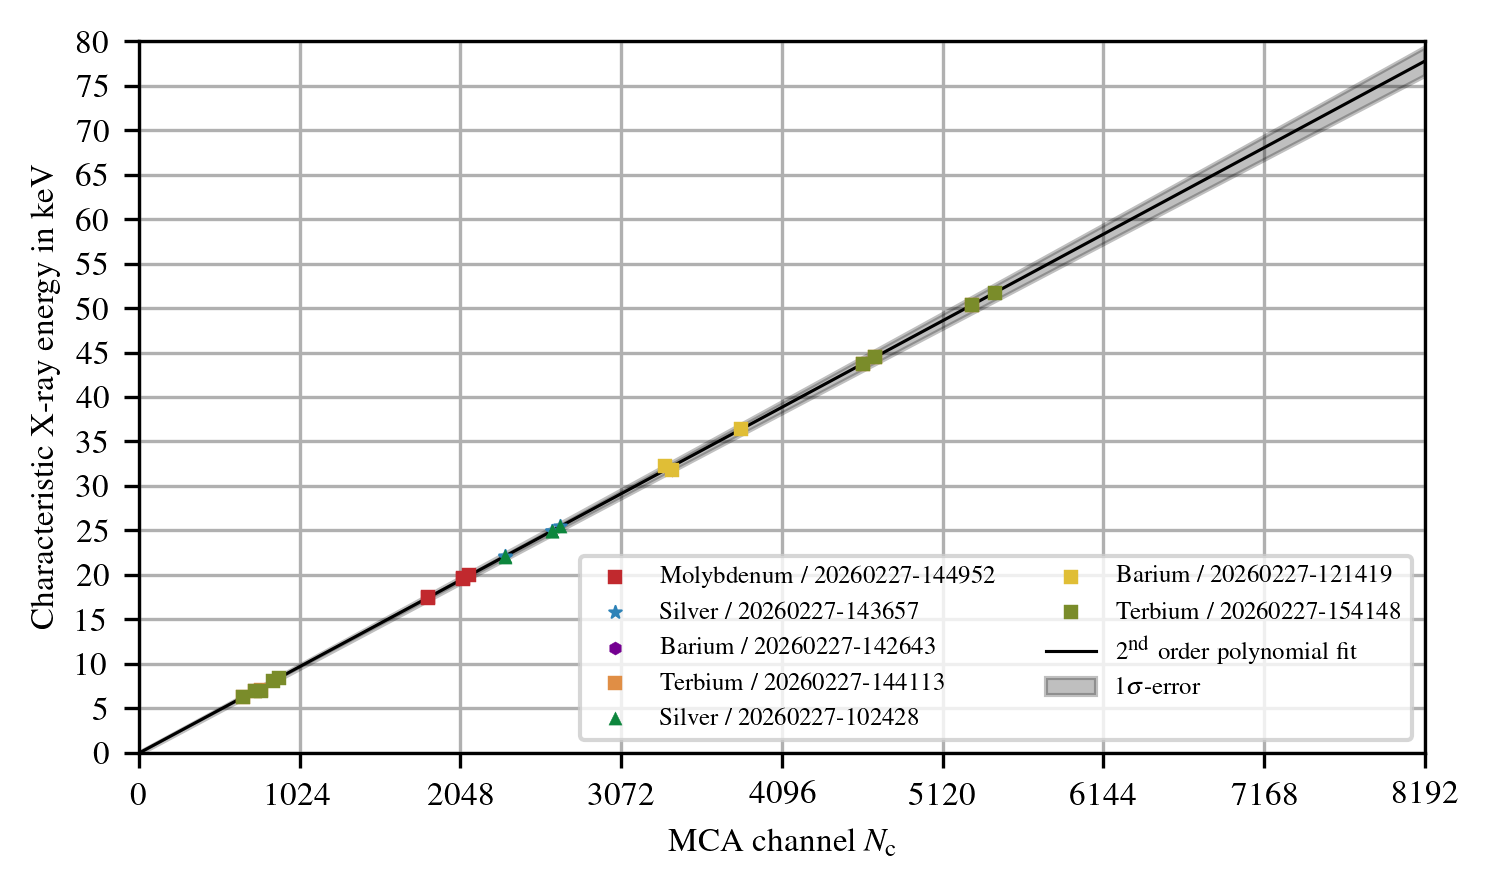

In [12]:
nameEnergyCal = 'MCA_8192-EG_10922'
measurementDate = 'Set_B_D'
lines_8192_10922, peaks_8192_10922, peaks_err_8192_10922, beta_export_8192_10922 = EnergyCal_8192_10922(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

nameEnergyCal = 'MCA_8192-EG_5461'
measurementDate = 'Set_B_D'
lines_8192_5461, peaks_8192_5461, peaks_err_8192_5461, beta_export_8192_5461 = EnergyCal_8192_5461(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

nameEnergyCal = 'MCA_8192-EG_4096'
measurementDate = 'Set_B_D'
lines_8192_4096, peaks_8192_4096, peaks_err_8192_4096, beta_export_8192_4096 = EnergyCal_8192_4096(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

nameEnergyCal = 'MCA_8192-EG_3770'
measurementDate = 'Set_B_D'
lines_8192_3770, peaks_8192_3770, peaks_err_8192_3770, beta_export_8192_3770 = EnergyCal_8192_3770(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

nameEnergyCal = 'MCA_8192-EG_2730'
measurementDate = 'Set_B_D'
lines_8192_2730, peaks_8192_2730, peaks_err_8192_2730, beta_export_8192_2730 = EnergyCal_8192_2730(nameEnergyCal=nameEnergyCal, measurementDate=measurementDate)

In [15]:
energy_data = {'1':{'MCA':8192, 
                    'EG':4096,
                    'E_ketek':6.67, 
                    'param':list(beta_export_8192_4096[0]),
                    'paramUn':list(beta_export_8192_4096[1])},
               '2':{'MCA':8192, 
                    'EG':2730,
                    'E_ketek':10,
                    'param':list(beta_export_8192_2730[0]),
                    'paramUn':list(beta_export_8192_2730[1])},
               '3':{'MCA':8192, 
                    'EG':10922,
                    'E_ketek':2.5,
                    'param':list(beta_export_8192_10922[0]),
                    'paramUn':list(beta_export_8192_10922[1])},
               '4':{'MCA':8192, 
                    'EG':3770,
                    'E_ketek':7.2,
                    'param':list(beta_export_8192_3770[0]),
                    'paramUn':list(beta_export_8192_3770[1])},
               '5':{'MCA':8192, 
                    'EG':5461,
                    'E_ketek':5.0,
                    'param':list(beta_export_8192_5461[0]),
                    'paramUn':list(beta_export_8192_5461[1])}
}

def EnergyCal_toJson(energy_data:dict):
     date_str = time.strftime("%d_%b_%Y", time.localtime())
     json_file_name = f'./energy_cali/{date_str}_eCali.json'
     with open(json_file_name, 'w', encoding='utf-8') as json_file:
          json.dump(energy_data, json_file, indent=4)
     print('ENERGY CALIBRATION: json file done.')

def EnergyCal_Overview_BD(data:dict):
    DPI = 300
    fig, ax = plt.subplots(figsize=(7,6), dpi = DPI)
    ins = ax.inset_axes([0.1,0.55,0.2,0.2])
    xlin = np.linspace(0,8192,8192)
    
    ax.scatter([],[],alpha=0, label='MCA channel width:')
    
    for s in ['3','5','1','4','2']:
        dataset = data[s]
        ax.plot(xlin, energy_func(dataset['param'], xlin), lw = 1, label=f'Manufacturer: {dataset['E_ketek']} eV / Energy Calibration: {round(dataset['param'][1],3)} eV', zorder=2)
        ax.fill_between(xlin,low_lin(dataset['param'],dataset['paramUn'],xlin),high_lin(dataset['param'],dataset['paramUn'],xlin), color='black', alpha=0.4, zorder=2)
        ins.plot(xlin, energy_func(dataset['param'], xlin), lw = 1, label=f'Manufacturer: {dataset['E_ketek']} eV / Energy Calibration: {round(dataset['param'][1],3)} eV', zorder=2)
        # ins.fill_between(xlin,low_lin(dataset['param'],dataset['paramUn'],xlin),high_lin(dataset['param'],dataset['paramUn'],xlin), color='black', alpha=0.4, zorder=2)
    
    
    
    ax.set_xlim(0,8193)
    ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    ax.set_yscale('linear')
    ax.set_ylim(10,80e3)
    
    ax.set_xlabel('MCA')
    ax.set_ylabel('Energy / keV')
    
    ax.set_yticks([10,10000,20000,30000,40000,50000,60000,70000,80000],[0,10,20,30,40,50,60,70,80])
    ax.grid(zorder=1)
    
    ins.set_xlim(0,5)
    ins.set_ylim(-100,100)
    ins.grid(zorder=1)
    ins.set_ylabel('Energy / eV')
    ins.set_xlabel('MCA')
    
    
    plt.legend()
    
    plt.savefig(f'./energy_cali/Comparison_030426.png', dpi=DPI)
    plt.savefig(f'./energy_cali/Comparison_030426.pdf', dpi=DPI)
    
    plt.show()

In [16]:
print(round(100*(2.387/2.5),4),round(100*(4.725/5),4),round(100*(6.306/6.67),4),round(100*(6.824/7.2),4),round(100*(9.49/10),4))
EnergyCal_toJson(energy_data)
# EnergyCal_Overview_BD(energy_data)

95.48 94.5 94.5427 94.7778 94.9
ENERGY CALIBRATION: json file done.
